In [1]:
import polars as pl
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

📂 Loading the  Dataset
🧠 Training on 815 days of history...
🔮 Testing on 204 unseen days...

🎯 AI MODEL ACCURACY: 49.02%

Detailed Wall Street Report Card:
              precision    recall  f1-score   support

           0       0.47      0.57      0.51        97
           1       0.52      0.42      0.46       107

    accuracy                           0.49       204
   macro avg       0.49      0.49      0.49       204
weighted avg       0.49      0.49      0.49       204



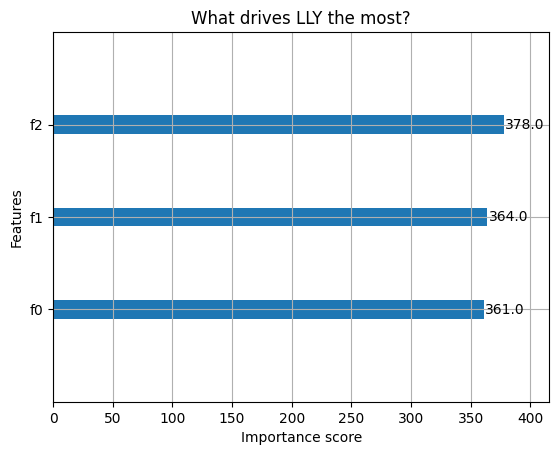

💾 Exporting the trained AI...
✅ Brain successfully saved as 'lly_xgboost_model.json'!


In [2]:
# 1. Load the Data Factory output
print("📂 Loading the  Dataset")
# IMPORTANT: Change to 1YR.csv if that is what your file is named!
df = pl.read_csv("../../data_pipelines/training_data_LLY_5YR.csv")

# Drop any missing values that might have slipped through
df = df.drop_nulls()

# 2. Sequential Split (80% Training, 20% Testing)
# Because it's time-series data, we can't shuffle it. We train on the past to predict the future.
split_idx = int(len(df) * 0.8)
train_df = df.head(split_idx)
test_df = df.tail(len(df) - split_idx)

# 3. Define Features and Convert to Numpy for XGBoost
features = ['RSI_14', 'ATR_14', 'FinBERT_Score']

X_train = train_df.select(features).to_numpy()
y_train = train_df.select("Target").to_numpy().ravel()

X_test = test_df.select(features).to_numpy()
y_test = test_df.select("Target").to_numpy().ravel()

print(f"🧠 Training on {len(X_train)} days of history...")
print(f"🔮 Testing on {len(X_test)} unseen days...")

# 4. Build and Train the XGBoost Model
model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42
)

# THIS IS WHERE THE AI LEARNS!
model.fit(X_train, y_train)

# 5. Make Predictions
predictions = model.predict(X_test)

# 6. Check the Scoreboard
accuracy = accuracy_score(y_test, predictions)
print("\n" + "="*40)
print(f"🎯 AI MODEL ACCURACY: {accuracy * 100:.2f}%")
print("="*40 + "\n")

print("Detailed Wall Street Report Card:")
print(classification_report(y_test, predictions))

# 7. Show which data point was the most important
xgb.plot_importance(model, importance_type='weight', title='What drives LLY the most?')
plt.show()

# 8. Save the trained Brain to a file
print("💾 Exporting the trained AI...")
model.save_model("lly_xgboost_model.json")
print("✅ Brain successfully saved as 'lly_xgboost_model.json'!")